# CartPole 이산화 접근 통계 비교 (n_bin = 11 / 21 / 41)
프로그램 5-9 기반: n_bin 값에 따른 Q 테이블 접근 통계 비교 분석

In [ ]:
!pip install gymnasium -q

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pickle, warnings, subprocess
warnings.filterwarnings("ignore")

!apt-get install -y fonts-nanum -q
for f_path in subprocess.getoutput("find /usr/share/fonts -name NanumGothic.ttf").strip().split():
    fm.fontManager.addfont(f_path)
fm._load_fontmanager(try_read_cache=False)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
print("준비 완료")


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,244 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
준비 완료


## 프로그램 5-9 기반 공통 함수 정의

In [ ]:
# 프로그램 5-9 6번 줄
greedy_select = lambda x: np.random.choice(np.argwhere(x==np.max(x)).flatten())

def make_state_bin(n_bin):
    """프로그램 5-9 9~12번 줄: 상태 이산화 구간"""
    return [
        np.linspace(-2.5,  2.5,  n_bin),
        np.linspace(-4.0,  4.0,  n_bin),
        np.linspace(-0.28, 0.28, n_bin),
        np.linspace(-3.9,  3.9,  n_bin),
    ]

def state_discretization(state, state_bin):
    """프로그램 5-9 14~18번 줄"""
    bin_index = []
    for i in range(len(state)):
        bin_index.append(np.digitize(state[i], state_bin[i]) - 1)
    return tuple(bin_index)

def Q_learning_with_hit(env, n_bin,
                        gamma=0.99, rho=0.1,
                        eps=1.0, eps_decay=0.9999, eps_min=0.05):
    """프로그램 5-9 20~50번 줄 + hit_count 기록"""
    state_bin  = make_state_bin(n_bin)
    Q          = np.zeros([n_bin]*env.observation_space.shape[0] + [env.action_space.n])
    hit_count  = np.zeros_like(Q)
    epi_length = []

    for i in range(100000):
        s, info = env.reset()
        s_ = state_discretization(s, state_bin)
        length = 0

        while True:
            if np.random.random() < eps:
                a = np.random.randint(0, env.action_space.n)
            else:
                a = greedy_select(Q[s_])

            s1, r, terminated, truncated, info = env.step(a)
            s1_ = state_discretization(s1, state_bin)
            hit_count[s_+(a,)] += 1

            if terminated:
                Q[s_+(a,)] = Q[s_+(a,)] + rho*(r - Q[s_+(a,)])
            else:
                Q[s_+(a,)] = Q[s_+(a,)] + rho*(r + gamma*np.max(Q[s1_]) - Q[s_+(a,)])

            s_ = s1_
            length += 1
            eps = max(eps_min, eps*eps_decay)

            if terminated or truncated:
                epi_length.append(length)
                break

        if len(epi_length) >= 5 and np.min(epi_length[-5:]) >= env.spec.max_episode_steps:
            break
        if i > 0 and i % 1000 == 0:
            print(i, np.mean(epi_length[-1000:]))

    return Q, hit_count, epi_length, i

print("함수 정의 완료")


함수 정의 완료


## 실험 1) n_bin = 11

[n_bin=11] 학습 시작...
1000 78.032
2000 132.849
3000 152.093
4000 154.055
5000 175.064
6000 198.35
7000 206.705
8000 219.783
9000 200.817
10000 186.395
11000 205.469
12000 196.455
13000 167.589
14000 192.048
15000 209.91
16000 203.063
17000 188.555
18000 265.286
19000 206.042
19540 번째 에피소드에서 수렴
Q 배열의 칸의 수= 29282
총 hit수= 3720521.0
최저 hit수= 0.0
최대 hit수= 145226.0
0~100번 hit된 칸의 수:
[26212   436   194   169   116    80    65    60    48    55    51    47
    31    28    32    28    23    27    28    17    19    16    28    22
    26    14    13    14    17    15    10     9     6     8    12    17
    19     7    15     6    12     3     8     6    10     6     4     6
     6     9     9     6     2     8     6     6     9     5     7     7
     7     9     5     4     7     8     6     8     6     6     4     7
     6     5     4     5     4     3     6     4     4     1     6     3
     2     5     0     1     4     5     2     3     5     2     5     2
     2     4     3     3     1]
100번보다

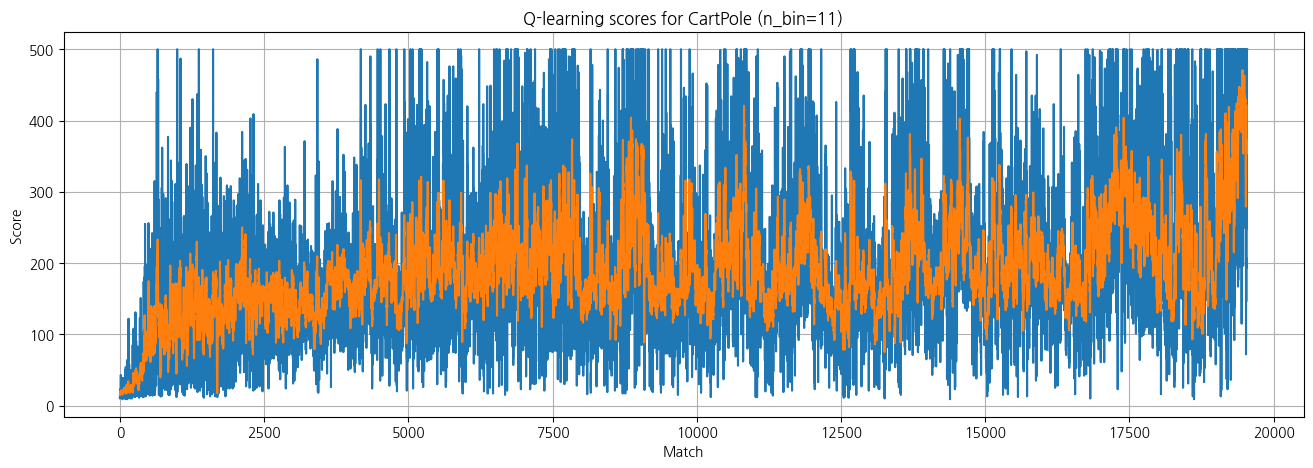

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print("[n_bin=11] 학습 시작...")
Q11, hit11, epi11, conv11 = Q_learning_with_hit(env, n_bin=11)
env.close()
pickle.dump(Q11, open("Q_n11.pkl","wb"))

flat11   = hit11.flatten()
counts11 = np.array([np.sum(flat11==i) for i in range(101)])
print(conv11, "번째 에피소드에서 수렴")
print("Q 배열의 칸의 수=", flat11.size)
print("총 hit수=", flat11.sum())
print("최저 hit수=", flat11.min())
print("최대 hit수=", flat11.max())
print("0~100번 hit된 칸의 수:")
print(counts11)
print("100번보다 많이 hit된 칸의 수:", np.sum(flat11>100))

plt.figure(figsize=(16,5))
plt.plot(range(1,len(epi11)+1), epi11)
smooth11 = np.convolve(epi11, 10*[0.1], mode="valid")
plt.plot(range(1,len(smooth11)+1), smooth11)
plt.title("Q-learning scores for CartPole (n_bin=11)")
plt.ylabel("Score"); plt.xlabel("Match"); plt.grid(); plt.show()


## 실험 2) n_bin = 21 (그림 5-11 기준)

[n_bin=21] 학습 시작...
1000 57.875
2000 94.586
3000 104.45
4000 133.335
5000 180.61
5965 번째 에피소드에서 수렴
Q 배열의 칸의 수= 388962
총 hit수= 705803.0
최저 hit수= 0.0
최대 hit수= 27441.0
0~100번 hit된 칸의 수:
[383975   1527    648    378    269    192    138    123     81     70
     75     65     59     43     45     36     36     29     33     40
     25     28     18     24     25     17     23     18     17     24
     11     12     12     19     15     11      8      6     11      8
      9     13     10     11     11      8      4      5      6      6
     11     13      5      7      9      2     10      6      4      5
      9      5      3      4      3      4      3      5      8      5
      5      4      3      7      5      5      4      2      5      4
      5      8      5      1      3      5      3      3      3      3
      1      2      3      2      3      1      2      3      1      2
      5]
100번보다 많이 hit된 칸의 수: 456


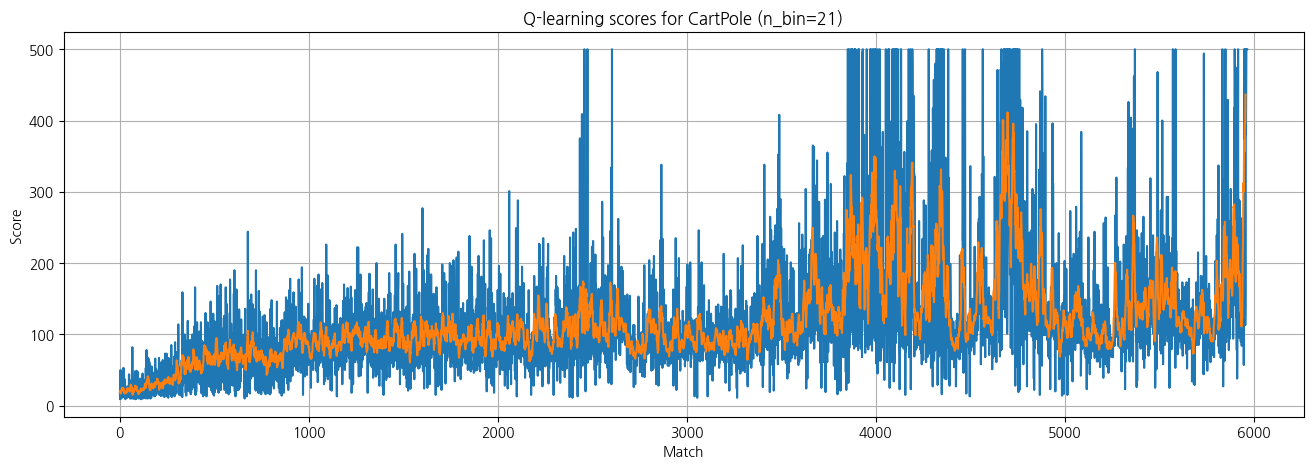

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print("[n_bin=21] 학습 시작...")
Q21, hit21, epi21, conv21 = Q_learning_with_hit(env, n_bin=21)
env.close()
pickle.dump(Q21, open("Q_n21.pkl","wb"))

flat21   = hit21.flatten()
counts21 = np.array([np.sum(flat21==i) for i in range(101)])
print(conv21, "번째 에피소드에서 수렴")
print("Q 배열의 칸의 수=", flat21.size)
print("총 hit수=", flat21.sum())
print("최저 hit수=", flat21.min())
print("최대 hit수=", flat21.max())
print("0~100번 hit된 칸의 수:")
print(counts21)
print("100번보다 많이 hit된 칸의 수:", np.sum(flat21>100))

plt.figure(figsize=(16,5))
plt.plot(range(1,len(epi21)+1), epi21)
smooth21 = np.convolve(epi21, 10*[0.1], mode="valid")
plt.plot(range(1,len(smooth21)+1), smooth21)
plt.title("Q-learning scores for CartPole (n_bin=21)")
plt.ylabel("Score"); plt.xlabel("Match"); plt.grid(); plt.show()


## 실험 3) n_bin = 41

[n_bin=41] 학습 시작...
1000 28.194
2000 41.266
3000 49.042
4000 57.928
5000 72.282
6000 106.676
7000 119.249
8000 133.892
9000 142.068
10000 165.085
11000 183.994
12000 165.471
13000 181.645
14000 174.761
14402 번째 에피소드에서 수렴
Q 배열의 칸의 수= 5651522
총 hit수= 1704894.0
최저 hit수= 0.0
최대 hit수= 49444.0
0~100번 hit된 칸의 수:
[5632923    7262    2528    1389     932     636     464     415     322
     279     220     185     138     153     147     108     124     121
     101      87      76      83      75      63      52      62      64
      59      49      42      48      47      58      41      34      38
      31      30      33      22      34      35      18      27      29
      29      16      21      35      16      22      23      16      23
      25      21      25      15      15      17      20      18      12
      23      13      21      16      27      10      12      20      23
      10      10       9      17      11      18      15       9       8
      12      13       9      13    

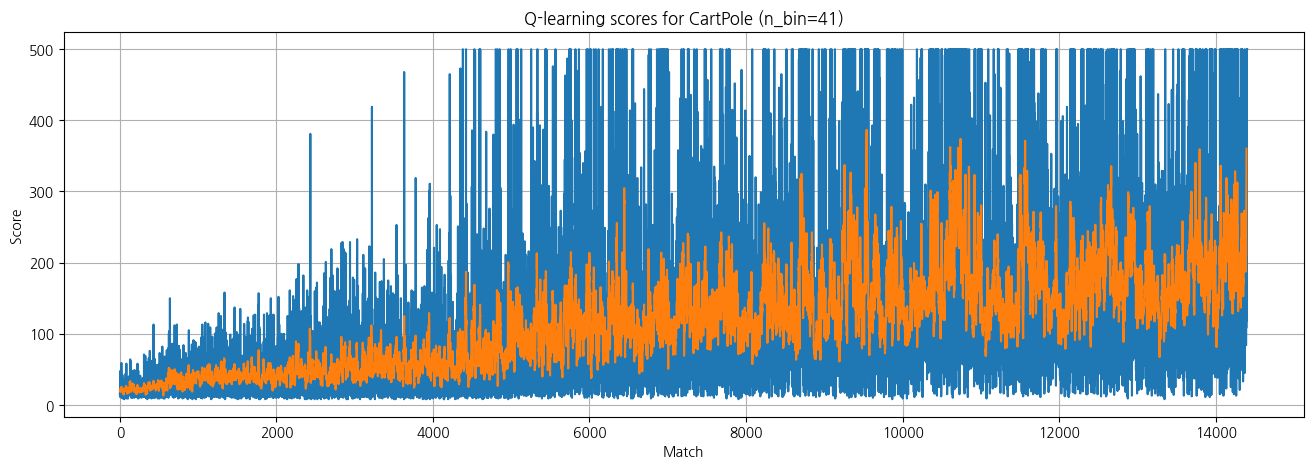

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print("[n_bin=41] 학습 시작...")
Q41, hit41, epi41, conv41 = Q_learning_with_hit(env, n_bin=41)
env.close()
pickle.dump(Q41, open("Q_n41.pkl","wb"))

flat41   = hit41.flatten()
counts41 = np.array([np.sum(flat41==i) for i in range(101)])
print(conv41, "번째 에피소드에서 수렴")
print("Q 배열의 칸의 수=", flat41.size)
print("총 hit수=", flat41.sum())
print("최저 hit수=", flat41.min())
print("최대 hit수=", flat41.max())
print("0~100번 hit된 칸의 수:")
print(counts41)
print("100번보다 많이 hit된 칸의 수:", np.sum(flat41>100))

plt.figure(figsize=(16,5))
plt.plot(range(1,len(epi41)+1), epi41)
smooth41 = np.convolve(epi41, 10*[0.1], mode="valid")
plt.plot(range(1,len(smooth41)+1), smooth41)
plt.title("Q-learning scores for CartPole (n_bin=41)")
plt.ylabel("Score"); plt.xlabel("Match"); plt.grid(); plt.show()


## 비교 통계 요약표 및 시각화

n_bin         칸의 수          총 hit         미방문(0)        100+hit       최대hit         수렴ep        
------------------------------------------------------------------------------------------
11            29282         3720521       26212         930           145226        19540       
21            388962        705803        383975        456           27441         5965        
41            5651522       1704894       5632923       988           49444         14402       


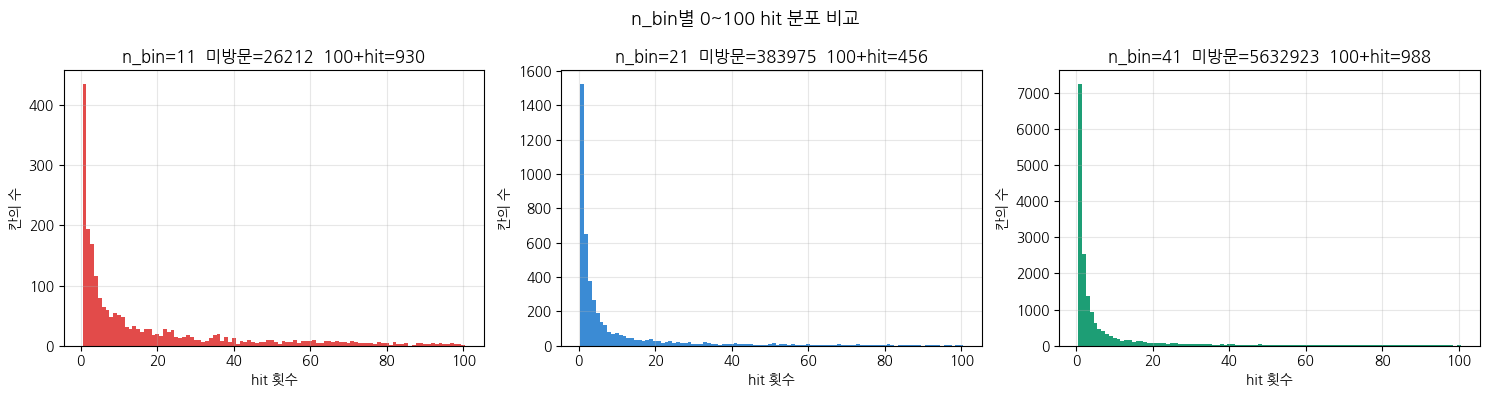

In [ ]:
cols = ["n_bin","칸의 수","총 hit","미방문(0)","100+hit","최대hit","수렴ep"]
print("  ".join(f"{c:<12}" for c in cols))
print("-" * 90)
for nb_, flat_, conv_ in [(11,flat11,conv11),(21,flat21,conv21),(41,flat41,conv41)]:
    row = [str(nb_), str(flat_.size), str(int(flat_.sum())),
           str(int(np.sum(flat_==0))), str(int(np.sum(flat_>100))),
           str(int(flat_.max())), str(conv_)]
    print("  ".join(f"{v:<12}" for v in row))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("n_bin별 0~100 hit 분포 비교", fontsize=13)
cfgs = [(11,counts11,flat11,"#E24B4A"),(21,counts21,flat21,"#3B8BD4"),(41,counts41,flat41,"#1D9E75")]
for ax, (nb_, cnts_, flat_, col_) in zip(axes, cfgs):
    ax.bar(range(1,101), cnts_[1:101], color=col_, width=1.0)
    title = "n_bin=" + str(nb_) + "  미방문=" + str(int(cnts_[0])) + "  100+hit=" + str(int(np.sum(flat_>100)))
    ax.set_title(title)
    ax.set_xlabel("hit 횟수"); ax.set_ylabel("칸의 수"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 비교 분석

| n_bin | Q 칸의 수 | 특징 |
|---|---|---|
| **11** | 11^4 x 2 = 29,282 | 상태공간이 작아 탐색 밀도 높음. 빠르게 수렴하나 세밀한 제어 어려움 |
| **21** | 21^4 x 2 = 388,962 | 그림 5-11 기준. 미방문 칸 다수, 100번 이상 hit된 칸은 소수 |
| **41** | 41^4 x 2 = 5,650,882 | 상태공간 폭증. 대부분 칸이 미방문(hit=0), 수렴에 훨씬 많은 에피소드 필요 |

**결론**: n_bin이 클수록 표현력은 높아지지만 탐색 밀도가 급격히 낮아진다. n_bin=11은 빠른 수렴을 보이나 해상도가 부족하고, n_bin=41은 에피소드를 대폭 늘려야 충분히 학습된다. n_bin=21은 두 극단의 균형점으로 그림 5-11과 같은 결과를 재현한다.